#1. Load Libraries

In [56]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


#2. Load Dataset

In [57]:
iris = load_iris(as_frame=True)
df = iris.frame

#3. Explore dataset

In [58]:
print(df.head())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [60]:
print(df.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)      target  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  


In [61]:
print(df.isnull().sum())

sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [62]:
print(df.duplicated().sum())

1


In [63]:
df = df.drop_duplicates()

In [64]:
print(df.duplicated().sum())

0


In [65]:
print(df["target"].value_counts()) # Distribution of target class

target
0    50
1    50
2    49
Name: count, dtype: int64


### Bar chart of target classes

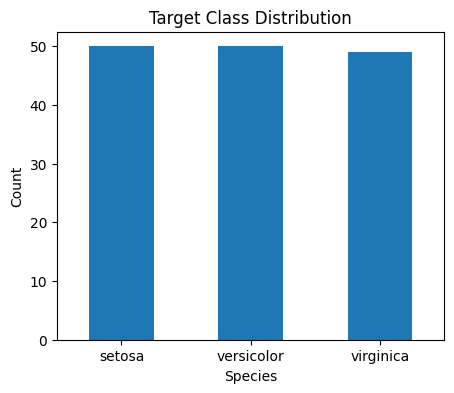

In [66]:
df["target"].value_counts().plot(
    kind="bar",
    figsize=(5,4)
)

plt.title("Target Class Distribution")
plt.xlabel("Species")
plt.ylabel("Count")
plt.xticks(
    [0, 1, 2],
    iris.target_names,
    rotation=0
)
plt.show()

## Histograms of All Features

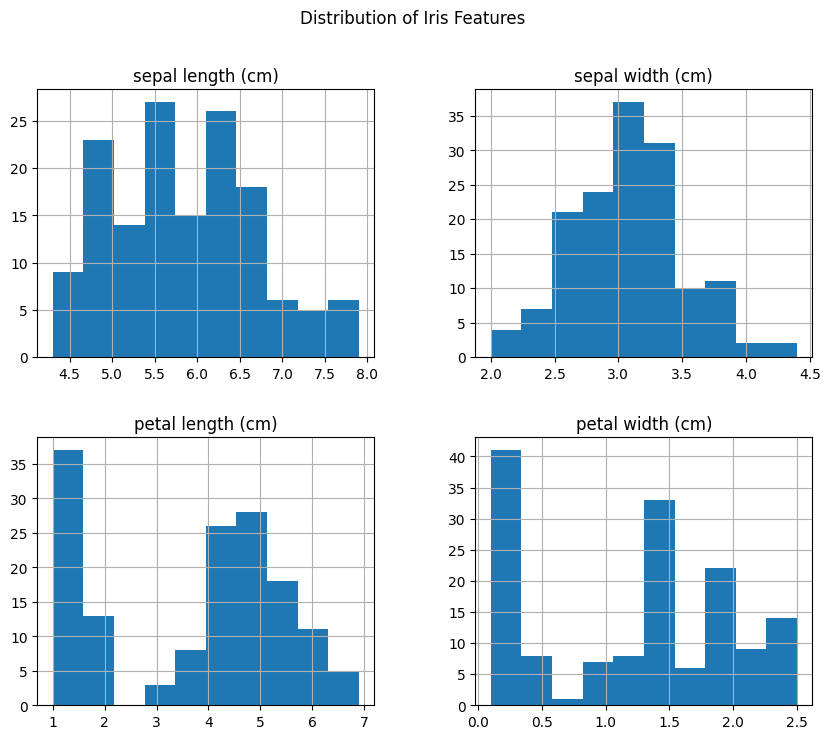

In [67]:
df.drop("target", axis=1).hist(figsize=(10,8))

plt.suptitle("Distribution of Iris Features")
plt.show()

### Boxplots

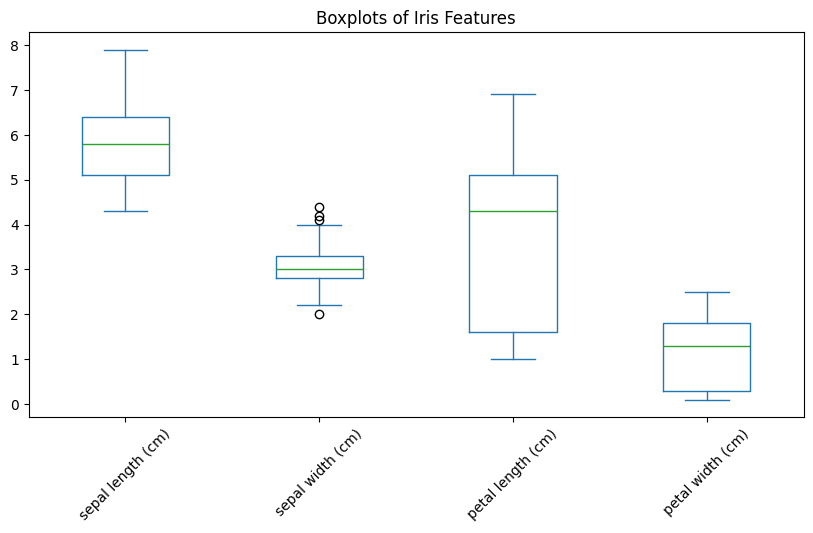

In [68]:
df.drop("target", axis=1).plot(
    kind="box",
    figsize=(10,5),
    rot=45
)

plt.title("Boxplots of Iris Features")
plt.show()

### Correlation Heatmap

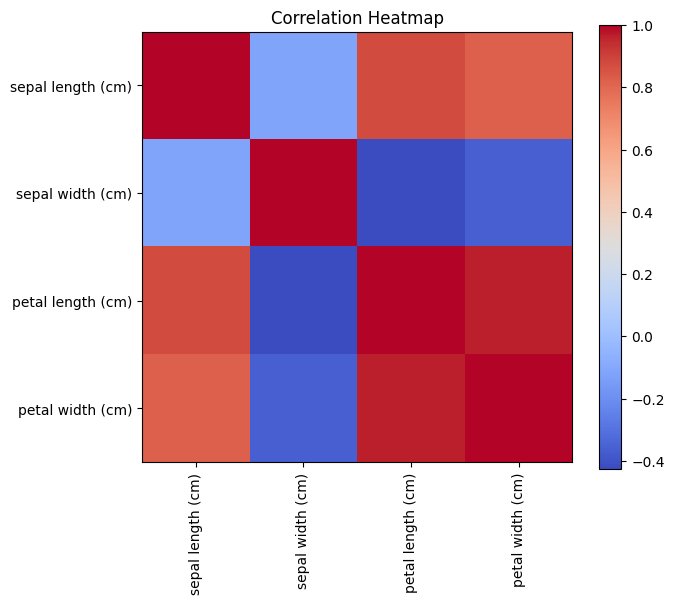

In [69]:
corr = df.drop("target", axis=1).corr()

plt.figure(figsize=(7,6))

plt.imshow(corr, cmap="coolwarm")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

#3. Remove Target from Dataset as it is Lable

In [73]:
X = df.drop("target", axis=1)
y = df["target"]

#4. Apply k-means Clustering

In [74]:
kmeans = KMeans(n_clusters=5,random_state=42)
kmeans.fit(X)
clusters = kmeans.labels_
print(clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 2 0 0 0 2 0 2 2 0 2 0 2 0 0 2 0 2 0 2 0 0
 0 0 0 0 0 2 2 2 2 0 2 0 0 0 2 2 2 0 2 2 2 2 2 0 2 2 3 0 4 3 3 4 2 4 3 4 3
 3 3 0 3 3 3 4 4 0 3 0 4 0 3 4 0 0 3 4 4 4 3 0 0 4 3 3 0 3 3 3 3 3 3 0 3 3
 0]


## 5. Use the Elbow Method to Find the Optimal Number of Clusters

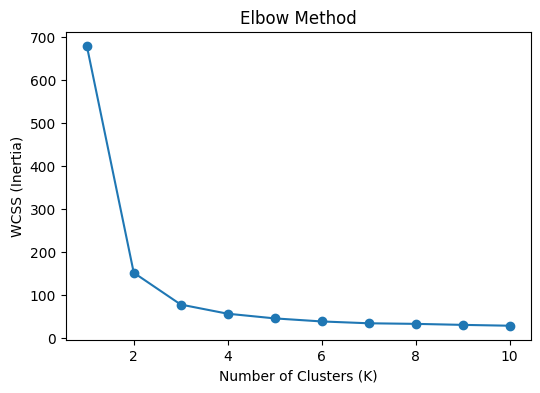

In [75]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.figure(figsize=(6,4))
plt.plot(range(1, 11),wcss,marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.show()

# 6. Use k value suggested by elbow method and again apply k-means

In [76]:
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(X)
clusters = kmeans.labels_
print(clusters)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 0 2 0 0 0 0 2 0 0 0 0
 0 0 2 2 0 0 0 0 2 0 2 0 2 0 0 2 2 0 0 0 0 0 2 0 0 0 0 2 0 0 0 0 0 0 2 0 0
 2]


# 7. Apply PCA
Apply Principal Component Analysis (PCA) to reduce the four features to two principal components (PC1 and PC2) for 2D visualization.

In [77]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 8. Visualize Clusters

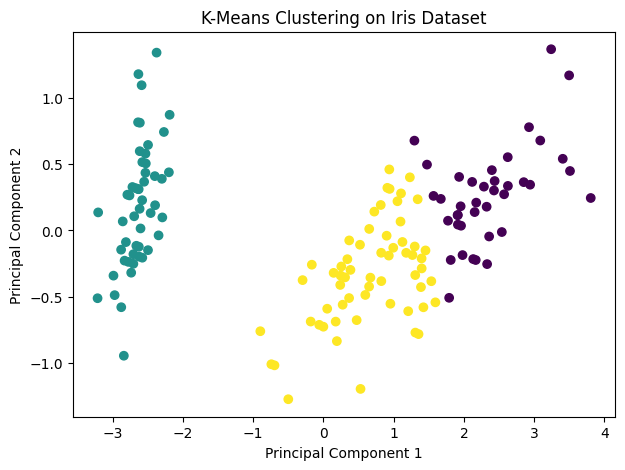

In [78]:
plt.figure(figsize=(7,5))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters
)

plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()